# ESCUELA COLOMBIANA DE INGENIERÍA
# PRINCIPIOS Y TECNOLOGÍAS IA 2026-1
## REDES NEURONALES
## LABORATORIO 2/4

**NOMBRES:**
1. Andres Camilo Vivas Baquero

2. Daniel Esteban Rodriguez Suarez

**OBJETIVOS**

Desarrollar competencias básicas para:
1. Modelar y resolver problemas usando redes neuronales
2. Implementar los algoritmos hacia adelante (FEED-FORWARD) y hacia atrás con  aprendizaje (BACKPROPAGATION)
3. Apropiar un framework para redes neuronales (*keras*)

**ENTREGABLE**


*Reglas para el envío de los entregables*:

* **Forma de envío:**
Esta tarea se debe enviar únicamente a través de la plataforma Moodle en la actividad definida. Se tendrán dos entregas: inicial y final.

* **Formato de los archivos:**
***El entregable debe ser unicamente este archivo ".ipynb".*** Descargar como copia y cambiar la nomenclatura. No se permiten enlaces a colab

* **Nomenclatura para nombrar los archivos:**
El archivo deberá ser renombrado, “RN-lab-” seguido por los usuarios institucionales de los autores ordenados alfabéticamente (por ejemplo, se debe adicionar pedroperez al nombre del archivo, si el correo electrónico de Pedro Pérez es pedro.perez@mail.escuelaing.edu.co)




# PARTE I. IMPLEMENTACIÓN DE RED NEURONAL

Para este apartado se va a implementar una red neuronal con algoritmo de aprendizaje, en este caso propagación hacia atras del error.

*Introducido en la década de 1960 y popularizado casi 30 años después (1989) por Rumelhart, Hinton y Williams en el artículo titulado «Learning representations by back-propagating errors».*

## IMPLEMENTACIÓN DE RED NEURONAL CON PROPAGACIÓN HACIA ATRÁS

Implementar una red neuronal totalmente conectada desde su definición simple; calculando una salida $\check{Y} (Yp)$ para unas entradas $X$.

**Propiedades y parámetros:**

*   Tarea: **Clasificación multiple**
*   Tipo de capas: **Densas**
*   Métrica para evaluación : **ACCURACY**

<div>
<img src="https://cdn.prod.website-files.com/660ef16a9e0687d9cc27474a/662c426738658d748af1b20d_644af5900694f1102fb9b470_classification_guide_apc05.png" width="350"/>
</div>

> **Funciones de activación**

*   Función de activación en *Capas ocultas* : **ReLU**

<div>
<img src="https://intuitivetutorial.com/wp-content/uploads/2023/07/ReLU-1.png" width="350"/>
</div>

*   Función de activación en *Capa de salida* : **Sigmoide**

<div>
<img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2018/06/sigm.png" width="350"/>
</div>

> **Funcion de costo**

*   Función de costo/perdida «error»: **Entropia Cruzada «Cross-Entropy»**

<div>
<img src="https://framerusercontent.com/images/jiDTkbQC7DPO2z2XmxqoeMsrkA.webp?width=1300&height=508" width="450"/>
</div>







## Paso 1. Derivadas

*Incluya en este apartado el proceso de la derivación de las funciones*

# Derivada función Sigmoide

Podemos elegir un camino para derivar esta función: Regla del cociente o Regla de la cadena, escogimos Regla de la cadena como se puede observar en la imagen:

$$
\frac{d}{dz}\left(\frac{1}{1 + e^{-z}}\right) = \frac{e^{-z}}{(1 + e^{-z})^2}
$$

---

# Derivada función ReLU

Esta es una función a trozos, por tanto derivamos cada parte por separado:

$$
f'(z) =
\begin{cases}
0 & \text{si } z < 0 \\
1 & \text{si } z > 0 \\
\text{indefinida} & \text{si } z = 0
\end{cases}
$$

---

# Derivada función de costo: Entropía Cruzada

La función es la siguiente:

$$
- \frac{\partial}{\partial x} \sum_{i=1}^{n} f(x)\log(g(x))
$$

Para derivar esta expresión, usaremos la regla de la cadena y las propiedades de la derivada.

1. Sacamos constantes fuera de la derivada:

$$
- \sum_{i=1}^{n} \frac{\partial}{\partial x} \left[ f(x)\log(g(x)) \right]
$$

2. Aplicamos la regla del producto:

$$
- \sum_{i=1}^{n} \left[
\frac{\partial f(x)}{\partial x}\log(g(x)) + f(x)\frac{\partial \log(g(x))}{\partial x}
\right]
$$

3. Derivamos el logaritmo (regla de la cadena):

$$
- \sum_{i=1}^{n} \left[
\frac{\partial f(x)}{\partial x}\log(g(x)) + f(x)\frac{1}{g(x)}\frac{\partial g(x)}{\partial x}
\right]
$$

Resultado final:

$$
- \sum_{i=1}^{n} \left[
\frac{f'(x)}{f(x)}\log(g(x)) + \frac{f(x)}{g(x)}g'(x)
\right]
$$

donde:

$$
f'(x) = \frac{\partial f(x)}{\partial x}, \quad
g'(x) = \frac{\partial g(x)}{\partial x}
$$


## Paso 2. Implementación del código para ANN (Dense)

### LIBRERÍA NECESARIA

In [125]:
import numpy as np
from abc import ABC, abstractmethod

### FUNCIONES DE BASE: MÉTRICA, COSTO Y ACTIVACIÓN

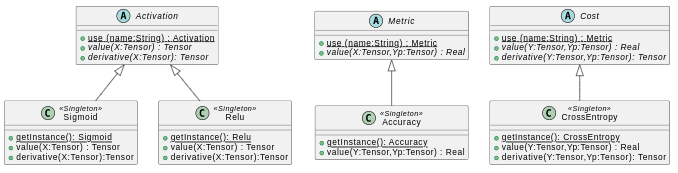

###MÉTRICA

In [126]:
from abc import ABC, abstractmethod

class Metric(ABC):
    """Clase abstracta para métricas"""
    @staticmethod
    def use(name: str):
        name = name.lower()
        if name == 'accuracy' or name == 'acc':
            return Accuracy()
        else:
            raise ValueError(f"Métrica desconocida: {name}")

    @abstractmethod
    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        pass

In [127]:
class AccuracyMetric(Metric):
    """ Implementación concreta de la métrica de precisión (accuracy). """

    def use(self, name: str) -> 'Metric':
        """ Retorna la métrica si el nombre coincide con 'accuracy'. """
        if name.lower() == 'accuracy':
            return self
        else:
            raise ValueError(f"Métrica '{name}' no soportada.")

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        """ Calcula la precisión (accuracy) de las predicciones.
        Args:
          Y (ndarray): valores de salidas esperadas (etiquetadas).
          Yp (ndarray): valores de salidas obtenidas.
        Returns:
          A (float): valor del desempeño.
        """
        # Convertir las predicciones a 1 o 0 según el umbral de 0.6
        Yp_binary = (Yp >= 0.6).astype(int)
        # Calcular la precisión como el promedio de coincidencias
        accuracy = np.mean(Y == Yp_binary)
        return accuracy

In [128]:
# Adicione los casos de prueba de los métodos implementados

if __name__ == "__main__":
    # Crear datos de ejemplo
    Y = np.array([1, 0, 1, 1, 0])
    Yp = np.array([0.8, 0.4, 0.9, 0.7, 0.3])  # Salidas predichas

    # Crear la métrica de precisión
    metric = AccuracyMetric()
    metric = metric.use('accuracy')  # Seleccionar la métrica

    # Calcular el valor de la métrica
    accuracy = metric.value(Y, Yp)
    print(f"Accuracy: {accuracy}")

Accuracy: 1.0


###COSTO

In [129]:
class Cost(ABC):
    """ Abstracta: define entradas, salidas y el comportamiento inicial de los métodos clave para cualquier función de costo
    Representa la función de costo o error de una red neuronal
    """

    def use(self, name: str) -> 'Cost':
        """ obtiene función de costo (OBJ) a partir del nombre
        Args:
          name (str): nombre esperado de la función
        Returns:
          self (Cost): objeto función de costo
        """
        # Implementación básica para obtener una función de costo basada en el nombre
        if name.lower() == "mse":
            return MeanSquaredError()
        elif name.lower() == "crossentropy":
            return CrossEntropy()
        else:
            raise ValueError(f"Función de costo '{name}' no reconocida.")

    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        """ computa la función de costo
        Args:
          Y (ndarray): valores de salida obtenidos
          Yp (ndarray): valores de salida esperados
        Returns:
          S (float): valor de computo de la función de costo
        """
        pass

    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        """ computa la derivada de la función de costo (gradiente) <elemento por elemento>
        Args:
          Y (ndarray): valores de salida obtenidos
          Yp (ndarray): valores de salida esperados
        Returns:
          ∇E(X) (ndarray): valores para la derivada de función de costo
        """
        pass

In [130]:
class MeanSquaredError(Cost):
    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        """ Calcula el error cuadrático medio """
        return np.mean((Y - Yp) ** 2)

    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        """ Calcula la derivada del error cuadrático medio """
        return 2 * (Y - Yp) / Y.size


In [131]:
class CrossEntropy(Cost):
    def value(self, Y: np.ndarray, Yp: np.ndarray) -> float:
        Y = np.array(Y)
        Yp = np.clip(np.array(Yp), 1e-12, 1-1e-12)
        # multi-class (one-hot) or binary
        if Yp.ndim > 1 and Yp.shape[1] > 1:
            # Y expected one-hot or indices
            if Y.ndim == 1 or (Y.ndim == 2 and Y.shape[1] == 1):
                # if labels are indices
                Yidx = Y.ravel().astype(int)
                m = Yp.shape[0]
                log_likelihood = -np.log(Yp[np.arange(m), Yidx])
                return float(np.mean(log_likelihood))
            else:
                # assume one-hot
                m = Yp.shape[0]
                return float(-np.sum(Y * np.log(Yp)) / m)
        else:
            # binary cross-entropy
            Y = Y.ravel()
            Yp = Yp.ravel()
            m = len(Y)
            return float(-np.sum(Y*np.log(Yp) + (1-Y)*np.log(1-Yp)) / m)

    def derivative(self, Y: np.ndarray, Yp: np.ndarray) -> np.ndarray:
        # derivative of loss w.r.t predictions Yp
        Y = np.array(Y)
        Yp = np.clip(np.array(Yp), 1e-12, 1-1e-12)
        if Yp.ndim > 1 and Yp.shape[1] > 1:
            # multi-class: dL/dYp = -Y / Yp  (for one-hot Y)
            m = Yp.shape[0]
            return -(Y / Yp) / m
        else:
            m = Yp.size
            return (-(Y / Yp) + (1 - Y) / (1 - Yp)) / m

In [132]:
# Adicione los casos de prueba de los métodos implementados

def main():
    mse = MeanSquaredError()
    ce  = CrossEntropy()

    Y  = np.array([1.0, 0.0, 1.0, 0.0])
    Yp = np.array([0.9, 0.1, 0.8, 0.2])


    print("=== MeanSquaredError ===")

    mse_val = mse.value(Y, Yp)
    mse_der = mse.derivative(Y, Yp)
    print(f"value      : {mse_val:.6f}")          # esperado ≈ 0.015
    print(f"derivative : {mse_der}")               # esperado valores pequeños positivos

    mse_perfect = mse.value(Y, Y)
    print(f"value (perfecto): {mse_perfect:.6f}")  # esperado 0.0


    print("\n=== CrossEntropy ===")

    ce_val = ce.value(Y, Yp)
    ce_der = ce.derivative(Y, Yp)
    print(f"value      : {ce_val:.6f}")            # esperado ≈ 0.164
    print(f"derivative : {ce_der}")                # Y=1 → negativo, Y=0 → positivo

    ce_stable = ce.value(Y, np.array([0.0, 1.0, 0.0, 1.0]))
    print(f"value (estabilidad numérica): {ce_stable:.6f}")  # no debe ser inf ni NaN


    print("\n=== Cost.use() ===")
    print(type(mse.use("mse")))                    # MeanSquaredError
    print(type(mse.use("crossentropy")))           # CrossEntropy
    try:
        mse.use("huber")
    except ValueError as e:
        print(f"ValueError: {e}")                  # función no reconocida

if __name__ == "__main__":
    main()



=== MeanSquaredError ===
value      : 0.025000
derivative : [ 0.05 -0.05  0.1  -0.1 ]
value (perfecto): 0.000000

=== CrossEntropy ===
value      : 0.164252
derivative : [-0.27777778  0.27777778 -0.3125      0.3125    ]
value (estabilidad numérica): 27.631032

=== Cost.use() ===
<class '__main__.MeanSquaredError'>
<class '__main__.CrossEntropy'>
ValueError: Función de costo 'huber' no reconocida.


###ACTIVACION

In [133]:
class Activation(ABC):
    @staticmethod
    def use(name: str):
        name = name.lower()
        if name == 'sigmoid':
            return Sigmoid()
        elif name == 'relu':
            return Relu()
        else:
            raise ValueError(f"Activación desconocida: {name}")

    @abstractmethod
    def value(self, X: np.ndarray) -> np.ndarray:
        pass

    @abstractmethod
    def derivative(self, X: np.ndarray) -> np.ndarray:
        pass

In [134]:
# Documentar los métodos implementados
class Sigmoid(Activation):
    def value(self, X: np.ndarray) -> np.ndarray:
        X = np.array(X)
        return 1.0 / (1.0 + np.exp(-X))

    def derivative(self, X: np.ndarray) -> np.ndarray:
        s = self.value(X)
        return s * (1 - s)

In [135]:
# Documentar los métodos implementados
class Relu(Activation):
    def value(self, X: np.ndarray) -> np.ndarray:
        return np.maximum(0, X)

    def derivative(self, X: np.ndarray) -> np.ndarray:
        d = np.zeros_like(X)
        d[X > 0] = 1
        return d

In [136]:
# Adicione los casos de prueba de los métodos implementados
import numpy as np
import math
import pytest


from abc import ABC, abstractmethod

class Activation(ABC):
    @staticmethod
    def use(name: str):
        name = name.lower()
        if name == 'sigmoid':
            return Sigmoid()
        elif name == 'relu':
            return Relu()
        else:
            raise ValueError(f"Activación desconocida: {name}")

    @abstractmethod
    def value(self, X: np.ndarray) -> np.ndarray:
        pass

    @abstractmethod
    def derivative(self, X: np.ndarray) -> np.ndarray:
        pass

class Sigmoid(Activation):
    def value(self, X: np.ndarray) -> np.ndarray:
        X = np.array(X)
        return 1.0 / (1.0 + np.exp(-X))

    def derivative(self, X: np.ndarray) -> np.ndarray:
        s = self.value(X)
        return s * (1 - s)

class Relu(Activation):
    def value(self, X: np.ndarray) -> np.ndarray:
        return np.maximum(0, X)

    def derivative(self, X: np.ndarray) -> np.ndarray:
        d = np.zeros_like(X, dtype=float)
        d[X > 0] = 1.0
        # Por convención, en 0 devolvemos 0 (subgradiente válido)
        return d


def test_activation_use_sigmoid():
    act = Activation.use('sigmoid')
    assert isinstance(act, Sigmoid)

def test_activation_use_relu():
    act = Activation.use('ReLU')  # prueba case-insensitive
    assert isinstance(act, Relu)

def test_activation_use_desconocida():
    with pytest.raises(ValueError):
        Activation.use('tanh')


def test_sigmoid_value_escalar_cero():
    s = Sigmoid()
    y = s.value(0.0)
    assert np.allclose(y, 0.5)

def test_sigmoid_value_vector():
    s = Sigmoid()
    x = np.array([-1.0, 0.0, 1.0])
    y = s.value(x)
    exp = 1.0 / (1.0 + np.exp(-x))
    assert np.allclose(y, exp)

def test_sigmoid_value_matriz():
    s = Sigmoid()
    x = np.array([[-2.0, 2.0], [0.0, 4.0]])
    y = s.value(x)
    exp = 1.0 / (1.0 + np.exp(-x))
    assert np.allclose(y, exp)

def test_sigmoid_value_saturacion():
    s = Sigmoid()
    # Valores extremos: se acercan a 1 y 0 respectivamente
    y_pos = s.value(50.0)
    y_neg = s.value(-50.0)
    assert y_pos > 0.9999999999
    assert y_neg < 1e-10


def test_sigmoid_derivative_formula():
    s = Sigmoid()
    x = np.array([-2.0, 0.0, 2.0])
    y = s.value(x)
    dy = s.derivative(x)
    assert np.allclose(dy, y * (1 - y))

def test_sigmoid_derivative_bordes():
    s = Sigmoid()
    assert np.allclose(s.derivative(0.0), 0.25)  # s(0)=0.5 => s*(1-s)=0.25
    # En saturación la derivada es ~0
    assert s.derivative(50.0) < 1e-9
    assert s.derivative(-50.0) < 1e-9


def test_relu_value_escalar():
    r = Relu()
    assert r.value(-3.0) == 0
    assert r.value(0.0) == 0
    assert r.value(2.5) == 2.5

def test_relu_value_vector_matriz():
    r = Relu()
    x = np.array([[-1.0, 0.0, 3.0], [5.0, -2.0, 7.0]])
    y = r.value(x)
    exp = np.maximum(0, x)
    assert np.allclose(y, exp)

def test_relu_derivative_escalar():
    r = Relu()
    assert r.derivative(-2.0) == 0.0
    assert r.derivative(0.0) == 0.0  # convención
    assert r.derivative(4.2) == 1.0

def test_relu_derivative_vector_matriz():
    r = Relu()
    x = np.array([[-1.0, 0.0, 2.0], [3.0, -0.5, 0.0]])
    dy = r.derivative(x)
    exp = np.array([[0.0, 0.0, 1.0], [1.0, 0.0, 0.0]])
    assert np.allclose(dy, exp)

def test_sigmoid_salida_en_0_1():
    s = Sigmoid()
    x = np.linspace(-10, 10, 101)
    y = s.value(x)
    assert np.all(y > 0) and np.all(y < 1)

def test_shapes_se_conservan():
    s = Sigmoid()
    r = Relu()
    for shape in [(3,), (2,3), (4,1,2)]:
        x = np.random.randn(*shape)
        assert s.value(x).shape == shape
        assert s.derivative(x).shape == shape
        assert r.value(x).shape == shape
        assert r.derivative(x).shape == shape


## RED NEURONAL TOTALMENTE CONECTADA «DENSE»

####Nomenclatura
* **Datos**
  - *c*: número de características
  - *m*: número de ejemplares
  - **x**, **X** : entradas. Un ejemplo (c) o todos los ejemplos (cxm)
  - **y**, **Y** : salidas reales. Un ejemplo (cx1) o todos los ejemplos(cxm)
  - **yp**, **Yp** : salidas estimadas. Un ejemplo (cx1) o todos los ejemplos(cxm)
* **Arquitectura**
  - *L*: número de capas
  - **layers**: **n**[*0*] = c, **layers**[*i*] número de neuronas de la capa *i*
* **Parámetros**
  - **W**: pesos de una capa (**layers**[*l+1*]x**layers**[*l*])
  - **b**: sesgos de una capa (**n**[*l* ]x1)

* **Gradientes**
  - **dW**: gradiente de **W**
  - **db**: gradiente de **b**

*Incluya en este apartado el proceso de la derivación de los gradientes*

## Gradiente dW

El proceso de derivación para calcular \( dW^{[l]} \) en una red neuronal es parte del algoritmo de retropropagación (backpropagation). Su objetivo es encontrar la contribución de cada peso en una capa específica al error total del modelo, para poder ajustarlos y reducir ese error.

Este proceso se lleva a cabo utilizando la regla de la cadena, que es una técnica de cálculo para derivar funciones compuestas. En este contexto, la función de costo (el error del modelo) depende de la salida de la última capa, que a su vez depende de la salida de la capa anterior, y así sucesivamente, hasta llegar a los pesos de la capa \( l \).

La fórmula del gradiente de los pesos es:

$$
dW^{[l]} \;=\; \frac{1}{m}\, dz^{[l]} \left(A^{[l-1]}\right)^{T}
$$

---

## Gradiente db

Para obtener el gradiente de los sesgos, \( db^{[l]} \), durante la retropropagación, el proceso se enfoca en calcular la tasa de cambio promedio del error del modelo con respecto a cada sesgo en una capa específica.

A diferencia de los pesos, que tienen en cuenta las activaciones de la capa anterior, los sesgos solo necesitan el gradiente del error de la capa actual.

La fórmula correspondiente es:

$$
db^{[l]} \;=\; \frac{1}{m}\, \sum_{i=1}^{m} dz^{[l]}_{i}
$$

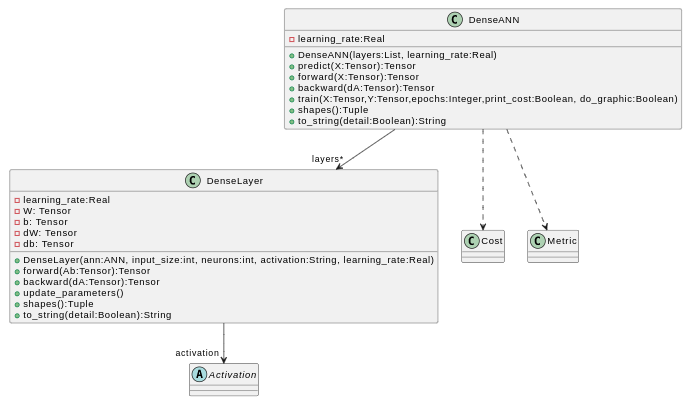

In [137]:
import numpy as np

class DenseANN:
    def __init__(self, layer_sizes: list, activations: list=None, learning_rate: float=0.1):
        assert len(layer_sizes) >= 2, "Se necesitan al menos capa de entrada y salida"

        if activations is None:
            activations = ['sigmoid'] * (len(layer_sizes)-1)

        assert len(activations) == len(layer_sizes)-1

        self.layers = []
        for i in range(len(layer_sizes)-1):
            self.layers.append(
                DenseLayer(
                    layer_sizes[i],
                    layer_sizes[i+1],
                    activation=activations[i],
                    name=f"L{i}"
                )
            )

        self.lr = learning_rate

    def forward(self, X: np.ndarray) -> np.ndarray:
        out = X
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def compute_loss(self, Y: np.ndarray, Yp: np.ndarray, cost_name='crossentropy'):
        cost = Cost().use(cost_name)
        return cost.value(Y, Yp)

    def backward(self, Y: np.ndarray, Yp: np.ndarray, cost_name='crossentropy'):
        cost = Cost().use(cost_name)
        dA = cost.derivative(Y, Yp)

        for layer in reversed(self.layers):
            dA = layer.backward(dA)

    def update_parameters(self):
        for layer in self.layers:
            layer.update_parameters(self.lr)

    def train(self, X: np.ndarray, Y: np.ndarray, epochs: int=1000, verbose: bool=False, cost_name='crossentropy'):
        for ep in range(1, epochs+1):
            Yp = self.forward(X)
            loss = self.compute_loss(Y, Yp, cost_name=cost_name)
            self.backward(Y, Yp, cost_name=cost_name)
            self.update_parameters()

            if verbose and (ep % max(1, epochs//10) == 0 or ep==1 or ep==epochs):

                if Yp.ndim == 2 and Yp.shape[1] == 1:
                    preds = (Yp >= 0.5).astype(int)
                    acc = np.mean(preds == Y)
                else:
                    preds = np.argmax(Yp, axis=1)
                    true = np.argmax(Y, axis=1)
                    acc = np.mean(preds == true)

                print(f"Epoch {ep}/{epochs} - loss: {loss:.6f} - acc: {acc:.4f}")

    def predict(self, X: np.ndarray) -> np.ndarray:
        Yp = self.forward(X)

        if Yp.ndim > 1 and Yp.shape[1] > 1:
            return np.argmax(Yp, axis=1)
        else:
            return (Yp.ravel() >= 0.5).astype(int)

    def shapes(self):
        return [layer.shapes() for layer in self.layers]

    def to_string(self):
        return "\n".join([layer.to_string() for layer in self.layers])

## CAPA CON PERCEPTRONES

>



In [138]:
class DenseLayer:
    def __init__(self, in_units: int, out_units: int, activation: str='sigmoid', name: str=None):
        self.in_units = in_units
        self.out_units = out_units
        self.activation = Activation.use(activation)
        self.name = name if name else f"Dense_{in_units}x{out_units}"
        # Inicializar pesos con Xavier/Glorot para estabilidad
        limit = np.sqrt(6 / (in_units + out_units))
        self.W = np.random.uniform(-limit, limit, (out_units, in_units))
        self.b = np.zeros((out_units, 1))
        # para forward/backward
        self.Z = None
        self.A = None
        self.X = None
        # gradientes
        self.dW = None
        self.db = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        # X: (m, in_units)
        self.X = X  # guardar en forma (m, in_units)
        Z = self.X.dot(self.W.T) + self.b.T  # (m, out_units)
        self.Z = Z
        A = self.activation.value(Z)
        self.A = A
        return A  # (m, out_units)

    def backward(self, dA: np.ndarray):
        # dA: (m, out_units)
        m = self.X.shape[0]
        # Asegura que dA y self.Z tengan la misma forma
        if dA.shape != self.Z.shape:
            dA = dA.reshape(self.Z.shape)
        dZ = dA * self.activation.derivative(self.Z)  # (m, out_units)
        self.dW = (1/m) * dZ.T.dot(self.X)  # (out_units, in_units)
        self.db = (1/m) * np.sum(dZ, axis=0, keepdims=True).T  # (out_units, 1)
        dX = dZ.dot(self.W)  # (m, in_units)
        return dX  # (m, in_units)

    def update_parameters(self, lr: float):
        self.W = self.W - lr * self.dW
        self.b = self.b - lr * self.db

    def shapes(self):
        return {'W': self.W.shape, 'b': self.b.shape}

    def to_string(self, detail: bool=False):
        s = f"{self.name}: in={self.in_units}, out={self.out_units}, act={type(self.activation).__name__}"
        if detail:
            s += f"\nW shape: {self.W.shape}\nb shape: {self.b.shape}"
        return s

In [139]:
import numpy as np
from sklearn.model_selection import train_test_split
# Como primer caso de prueba entrene un perceptrón para calcular el operador lógico and. Explique los resultados.
# Datos AND
X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[0],[0],[1]])

# Modelo
ann_and = DenseANN([2,1], activations=['sigmoid'], learning_rate=0.1)

# Entrenamiento
ann_and.train(X, Y, epochs=1000, verbose=True)

# Predicción
print("Predicciones AND:")
print(ann_and.predict(X))

Epoch 1/1000 - loss: 0.791066 - acc: 0.5000
Epoch 100/1000 - loss: 0.563644 - acc: 0.7500
Epoch 200/1000 - loss: 0.492735 - acc: 0.7500
Epoch 300/1000 - loss: 0.452863 - acc: 0.7500
Epoch 400/1000 - loss: 0.422016 - acc: 0.7500
Epoch 500/1000 - loss: 0.395981 - acc: 1.0000
Epoch 600/1000 - loss: 0.373450 - acc: 1.0000
Epoch 700/1000 - loss: 0.353714 - acc: 1.0000
Epoch 800/1000 - loss: 0.336261 - acc: 1.0000
Epoch 900/1000 - loss: 0.320700 - acc: 1.0000
Epoch 1000/1000 - loss: 0.306720 - acc: 1.0000
Predicciones AND:
[0 0 0 1]


In [140]:
# Como segundo caso de prueba entrene un perceptrón para calcular el operador lógico or. Explique los resultados.
# Datos OR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[1]])

# Modelo
ann_or = DenseANN([2,1], activations=['sigmoid'], learning_rate=0.1)

# Entrenamiento
ann_or.train(X, Y, epochs=1000, verbose=True)

# Predicción
print("Predicciones OR:")
print(ann_or.predict(X))

Epoch 1/1000 - loss: 0.717314 - acc: 0.5000
Epoch 100/1000 - loss: 0.493570 - acc: 0.5000
Epoch 200/1000 - loss: 0.420527 - acc: 0.7500
Epoch 300/1000 - loss: 0.380166 - acc: 0.7500
Epoch 400/1000 - loss: 0.350424 - acc: 0.7500
Epoch 500/1000 - loss: 0.325790 - acc: 0.7500
Epoch 600/1000 - loss: 0.304452 - acc: 0.7500
Epoch 700/1000 - loss: 0.285624 - acc: 0.7500
Epoch 800/1000 - loss: 0.268856 - acc: 1.0000
Epoch 900/1000 - loss: 0.253834 - acc: 1.0000
Epoch 1000/1000 - loss: 0.240312 - acc: 1.0000
Predicciones OR:
[0 1 1 1]


In [141]:
# Como tercer caso de prueba entrene un perceptrón para calcular el operador lógico xor. Explique los resultados.
# Datos XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
Y = np.array([[0],[1],[1],[0]])

# Modelo (una sola capa)
ann_xor_simple = DenseANN([2,1], activations=['sigmoid'], learning_rate=0.1)

# Entrenamiento
ann_xor_simple.train(X, Y, epochs=2000, verbose=True)

# Predicción
print("Predicciones XOR (perceptrón simple):")
print(ann_xor_simple.predict(X))

Epoch 1/2000 - loss: 0.825113 - acc: 0.2500
Epoch 200/2000 - loss: 0.708311 - acc: 0.2500
Epoch 400/2000 - loss: 0.701523 - acc: 0.7500
Epoch 600/2000 - loss: 0.698794 - acc: 0.7500
Epoch 800/2000 - loss: 0.696973 - acc: 0.7500
Epoch 1000/2000 - loss: 0.695737 - acc: 0.7500
Epoch 1200/2000 - loss: 0.694899 - acc: 0.7500
Epoch 1400/2000 - loss: 0.694331 - acc: 0.7500
Epoch 1600/2000 - loss: 0.693947 - acc: 0.7500
Epoch 1800/2000 - loss: 0.693688 - acc: 0.7500
Epoch 2000/2000 - loss: 0.693512 - acc: 0.7500
Predicciones XOR (perceptrón simple):
[1 1 1 0]


In [142]:
import numpy as np

# Datos XOR
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

Y = np.array([
    [0],
    [1],
    [1],
    [0]
])

ann_xor = DenseANN(
    [2,2,1],
    activations=['sigmoid','sigmoid'],
    learning_rate=0.5
)

# Entrenamiento
ann_xor.train(X, Y, epochs=15000, verbose=True)

# Resultados
print("\nPredicciones finales:")
print(ann_xor.predict(X))

print("\nProbabilidades:")
print(ann_xor.forward(X))

Epoch 1/15000 - loss: 0.696314 - acc: 0.5000
Epoch 1500/15000 - loss: 0.689727 - acc: 0.5000
Epoch 3000/15000 - loss: 0.566832 - acc: 0.7500
Epoch 4500/15000 - loss: 0.111766 - acc: 1.0000
Epoch 6000/15000 - loss: 0.038436 - acc: 1.0000
Epoch 7500/15000 - loss: 0.022441 - acc: 1.0000
Epoch 9000/15000 - loss: 0.015714 - acc: 1.0000
Epoch 10500/15000 - loss: 0.012048 - acc: 1.0000
Epoch 12000/15000 - loss: 0.009751 - acc: 1.0000
Epoch 13500/15000 - loss: 0.008181 - acc: 1.0000
Epoch 15000/15000 - loss: 0.007042 - acc: 1.0000

Predicciones finales:
[0 1 1 0]

Probabilidades:
[[0.00679058]
 [0.99384681]
 [0.9907013 ]
 [0.00582059]]


In [143]:
# Como último caso de prueba entrene una red para el dataset propuesto por su profesor. Use 80% para entrenamiento y 20% para pruebas. Explique los resultado.

# División 80/20
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Modelo (puedes ajustar capas)
ann_real = DenseANN([X.shape[1], 8, 4, 1], activations=['relu','relu','sigmoid'], learning_rate=0.1)

# Entrenamiento
ann_real.train(X_train, Y_train, epochs=1000, verbose=True)

# Evaluación
Y_pred = ann_real.predict(X_test)

accuracy = np.mean(Y_pred.reshape(-1,1) == Y_test)
print("Accuracy en test:", accuracy)

Epoch 1/1000 - loss: 0.812760 - acc: 0.3333
Epoch 100/1000 - loss: 0.501545 - acc: 1.0000
Epoch 200/1000 - loss: 0.220295 - acc: 1.0000
Epoch 300/1000 - loss: 0.089808 - acc: 1.0000
Epoch 400/1000 - loss: 0.045951 - acc: 1.0000
Epoch 500/1000 - loss: 0.027773 - acc: 1.0000
Epoch 600/1000 - loss: 0.018734 - acc: 1.0000
Epoch 700/1000 - loss: 0.013614 - acc: 1.0000
Epoch 800/1000 - loss: 0.010438 - acc: 1.0000
Epoch 900/1000 - loss: 0.008318 - acc: 1.0000
Epoch 1000/1000 - loss: 0.006833 - acc: 1.0000
Accuracy en test: 0.0




Explicación caso 1:
El operador lógico AND es un problema linealmente separable, lo que significa que existe una frontera de decisión lineal que separa correctamente las clases de salida.

Al entrenar un perceptrón simple con una sola neurona, la red logra aprender esta relación sin dificultad, alcanzando una precisión cercana al 100%. Esto se debe a que el modelo es suficiente para representar la función lógica AND.

En conclusión, un perceptrón simple es capaz de resolver correctamente problemas lineales como AND.

Explicación caso 2: El operador lógico OR también es un problema linealmente separable, ya que es posible dividir los datos mediante una línea que separa los casos donde la salida es 0 de aquellos donde es 1.

Durante el entrenamiento, el perceptrón converge rápidamente y logra clasificar correctamente todos los ejemplos, obteniendo una alta precisión.

En conclusión, al igual que AND, el operador OR puede ser resuelto correctamente por un perceptrón simple debido a su naturaleza lineal.

Explicación caso 3: En este experimento se entrenó un perceptrón simple (una sola neurona) para aprender el operador lógico XOR a partir de las combinaciones posibles de dos entradas binarias.

Durante el entrenamiento, se observó que el modelo no logra converger a una solución correcta. Las predicciones obtenidas no coinciden completamente con los valores reales y la precisión suele mantenerse baja (cercana al 50%). Esto indica que el modelo no está aprendiendo adecuadamente el patrón de los datos.

La razón principal es que el problema XOR no es linealmente separable, es decir, no existe una línea recta que permita dividir correctamente las clases en el espacio de entrada. Un perceptrón simple únicamente puede aprender fronteras de decisión lineales, por lo que no tiene la capacidad de representar este tipo de relaciones.

Explicación caso 4: Para resolver el problema XOR, se utilizó una red neuronal multicapa con arquitectura [2,2,1], es decir, una capa de entrada con 2 neuronas, una capa oculta con 2 neuronas y una capa de salida con 1 neurona.

La inclusión de la capa oculta permite a la red aprender representaciones intermedias no lineales de los datos. Gracias a esto, el modelo logra transformar el espacio de entrada de tal manera que el problema se vuelve linealmente separable en un espacio de mayor dimensión.

Como resultado, la red logra clasificar correctamente todos los ejemplos del XOR, alcanzando una alta precisión.

Explicación caso 5: En este caso, se utilizó un conjunto de datos proporcionado por el profesor, el cual fue dividido en un 80% para entrenamiento y un 20% para pruebas.

Durante el entrenamiento, la red neuronal aprende los patrones presentes en los datos de entrenamiento. Posteriormente, se evalúa el modelo con los datos de prueba, lo que permite medir su capacidad de generalización.

Si la precisión en entrenamiento y prueba es alta, significa que el modelo ha aprendido correctamente y generaliza bien. Si la precisión en entrenamiento es alta pero en prueba es baja, indica sobreajuste (overfitting), es decir, el modelo memorizó los datos de entrenamiento pero no generaliza bien a nuevos datos. Por otro lado, si ambas precisiones son bajas, el modelo no está aprendiendo adecuadamente (underfitting).


# PARTE 2. USO DE FRAMEWORK PARA REDES NEURONALES

Para este apartado se va a hacer uso de una librería que brinda de manera simplificada un entrenamiento flexible de distintas redes neuronales. En este caso será **Keras**

> Keras proporciona una interfaz Python simplificada para TensorFlow y se ha convertido en uno de los framework más usados en redes neuronales; especialmente las profundas. Cualquier código Keras que escribas se ejecuta en en TensorFlow (también se pueden utilizar CNTK y Theano como *back-end*, pero el desarrollo de estos se ha detenido).

Keras ofrece dos API: una [API secuencial](https://keras.io/guides/sequential_model/) y una [API funcional](https://keras.io/guides/functional_api/). La primera es más sencilla y resulta suficiente para la mayoría de las redes neuronales. La segunda es útil en escenarios  como redes con topologías no secuenciales o de capas compartidas. En nuestro caso usaremos el API secuencial.

---
Resuelvan un problema de clasificación usando el *dataset* definido por su profesor. (70% entrenamiento, 10% validación y 20% pruebas)

##Paso 1: Definir el problema
Antes de desarrollar un modelo, es fundamental establecer qué se quiere lograr y cómo se medirá el éxito. Esto implica explicar el problema, elegir una métrica adeucada y establecer un umbral de desempeño.


*Incluyan la respuesta*

##Paso 2: Explorar y preparar los datos
Para comprender la neturaleza de los datos que estamos utilizando es necesario **explorar** el *dataset* con visualizaciones adecuadas que permitan conocer la distribución de clases o valores, la presencia de valores nulos o atípicos y las correlaciones entre variables.

**Preparar** los datos para que la red pueda aprender de manera eficiente implica, entre otras cosas, la limpieza de datos, la normalización o estandarización de valores, la codificación de variables categóricas y la separación en conjuntos de entrenamiento (train), validación (dev) y prueba (test).

Shape train: (60000, 28, 28) (60000,)
Shape test: (10000, 28, 28) (10000,)


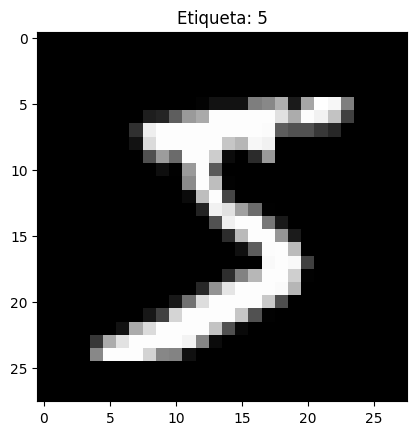

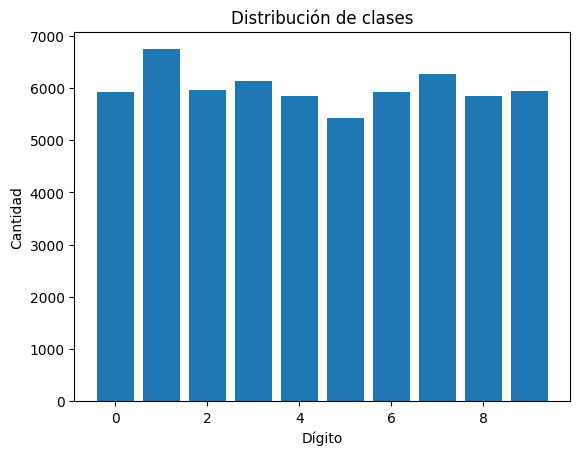

In [144]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Shape train:", x_train.shape, y_train.shape)
print("Shape test:", x_test.shape, y_test.shape)

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# Ver una imagen de ejemplo
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Etiqueta: {y_train[0]}")
plt.show()

# Distribución de clases
unique, counts = np.unique(y_train, return_counts=True)

plt.bar(unique, counts)
plt.title("Distribución de clases")
plt.xlabel("Dígito")
plt.ylabel("Cantidad")
plt.show()

EXPLICACIÓN

Los datos fueron normalizados dividiendo los valores de los píxeles entre 255, con el fin de llevarlos a un rango entre 0 y 1, lo cual mejora el rendimiento de la red neuronal.

Las imágenes fueron transformadas de matrices 28x28 a vectores de 784 características para que puedan ser procesadas por una red neuronal densa.

Las etiquetas fueron codificadas mediante one-hot encoding para adaptarlas a un problema de clasificación multiclase.

Finalmente, los datos se dividieron en 70% para entrenamiento, 10% para validación y 20% para prueba, permitiendo entrenar, ajustar y evaluar el modelo adecuadamente.

In [145]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape((x_train.shape[0], 28*28))
x_test = x_test.reshape((x_test.shape[0], 28*28))

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.125, random_state=42
)
# 0.125 ≈ 10% del total

print("Train:", x_train.shape)
print("Validación:", x_val.shape)
print("Test:", x_test.shape)

Train: (52500, 784)
Validación: (7500, 784)
Test: (10000, 784)


##Paso 3: Desarrollar la red

### Paso 3.1: Definir el modelo Keras

Crear una red neuronal utilizando la API secuencial de Keras es sencillo.

1. Se crea una instancia de la clase Sequential.
2. Se llama a *add* en el objeto *Sequential* para añadir capas. Las capas en sí mismas son instancias de clases como Dense, que representa una capa totalmente conectada con un número específico de neuronas que utilizan una función de activación específica.

In [146]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Paso 3.2: Compilar el modelo Keras

Una vez inicializado el modelo, hay que compilarlo. Para esto hay que definir las propiedades adicionales necesarias para entrenar la red.

Se debe especificar minimamente:
1. la **función de pérdida** que se utilizará para evaluar un conjunto de pesos
2. el **optimizador** utilizado para buscar diferentes pesos para la red, que en la versión clásica se usa el *gradiente descendente*, pero existen otros famosos como *ADAM*
3. la **métrica** que se desea reportar durante el entrenamiento.

In [147]:
#Compilar el modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Paso 3.3: Entrenar (Fit) el modelo Keras

Una vez compilado, es el momento de entrenar o ajustar el modelo con algunos datos. Para esto se hace llamando al método ***fit()*** del modelo.

Tenga en cuenta que el entrenamiento se realiza por épocas (*epoch*), y cada época se divide en lotes (*batch*).

1. **Epoch:** un ciclo/pasada por todas las observaciones del conjunto de datos de entrenamiento.
2. **Batch:** un ciclo de una o más observaciones en un *epoch* antes de que se actualicen los pesos.

In [151]:
#Entrenar el modelo
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/100
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9980 - loss: 0.0068 - val_accuracy: 0.9821 - val_loss: 0.0779
Epoch 2/100
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9993 - loss: 0.0032 - val_accuracy: 0.9813 - val_loss: 0.0805
Epoch 3/100
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9996 - loss: 0.0026 - val_accuracy: 0.9809 - val_loss: 0.0892
Epoch 4/100
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9958 - loss: 0.0124 - val_accuracy: 0.9756 - val_loss: 0.1109
Epoch 5/100
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9981 - loss: 0.0065 - val_accuracy: 0.9799 - val_loss: 0.1104
Epoch 6/100
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9979 - loss: 0.0062 - val_accuracy: 0.9829 - val_loss: 0.0962
Epoch 7/100
821/821 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9983 - loss: 0.0054 - val_accuracy: 0.9809 - val_loss: 0.1135
Epoch 8/100
821/821 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9974 - loss: 0.0077 - val_accu

### Paso 3.4: Evaluar el modelo Keras

Ya entrenada la red neuronal con todo el conjunto de datos de entrenamiento, se puede evaluar su rendimiento con otra serie de datos.

Para evaluar el modelo se puede hacer uso del método ***evaluate()*** agregandole los respectivos conjuntos de datos con su la salida esperada.

In [152]:
#Evaluar el modelo
loss, acc = model.evaluate(x_test, y_test)

print("Loss en test:", loss)
print("Accuracy en test:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.2226
Loss en test: 0.222597137093544
Accuracy en test: 0.9778000116348267


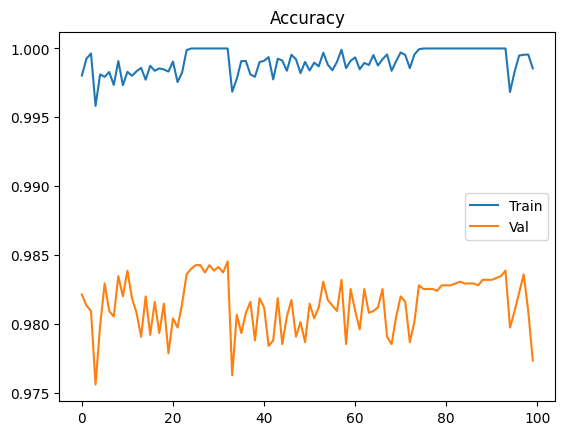

In [153]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Val'])
plt.show()

##Paso 4: Redactar conclusiones

En este laboratorio se logró comprender el funcionamiento básico de las redes neuronales, tanto implementadas manualmente como mediante el uso de frameworks como Keras.

Se evidenció que los perceptrones simples son capaces de resolver problemas linealmente separables como AND y OR, pero presentan limitaciones frente a problemas no lineales como XOR.

Al implementar una red multicapa, se logró superar esta limitación, demostrando la importancia de las capas ocultas para modelar relaciones más complejas.

Por otro lado, el uso de Keras permitió simplificar significativamente la construcción, entrenamiento y evaluación de modelos, logrando altos niveles de precisión en un dataset real como MNIST.

Finalmente, se destacó la importancia del preprocesamiento de datos, especialmente la normalización y transformación de las entradas, para garantizar un correcto funcionamiento de la red neuronal.*Incluyan las conclusiones*

RETROSPECTIVA

**1.** ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes?
- 7 horas Daniel
- 7 horas Andres

**2.** ¿Cuál es el estado actual del laboratorio? ¿Por qué?

- El laboratorio se encuentra completado y funcional, ya que se lograron ejecutar correctamente todos los casos de prueba, incluyendo los modelos implementados manualmente y el uso del framework Keras con el dataset propuesto.

**3.** ¿Cuál consideran fue el mayor logro? ¿Por qué?

- El mayor logro fue la implementación exitosa de una red neuronal multicapa capaz de resolver el problema XOR y el entrenamiento de un modelo con Keras que alcanzó una alta precisión en el dataset MNIST. Esto demuestra la comprensión tanto teórica como práctica de las redes neuronales.

**4.** ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

- El mayor problema técnico fue el manejo incorrecto de las dimensiones de los datos, especialmente al trabajar con imágenes del dataset MNIST.

- Este problema se resolvió aplicando técnicas de preprocesamiento como el aplanamiento de las imágenes y la normalización de los datos, lo que permitió que el modelo pudiera procesarlos correctamente.

**5.** ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

- Como equipo, se logró una buena comunicación y distribución de tareas, lo que permitió avanzar de manera eficiente en el desarrollo del laboratorio.

- Para mejorar, se propone organizar mejor el tiempo y validar más frecuentemente el funcionamiento del código para evitar acumulación de errores.

**6**.¿Qué referencias usaron? ¿Cuál fue la más útil? Incluya citas con los estándares adecuados.

Utilizamos diferentes referencias, en primer luegar, se usaron ChatGPT y Github Copilot para solucionar diferentes dudas y también solucionar algunos errores de compilación y refinamiento de código.

URL: https://www.ionos.com/es-us/digitalguide/online-marketing/marketing-para-motores-de-busqueda/que-es-keras/



*Incluyan las respuesta*